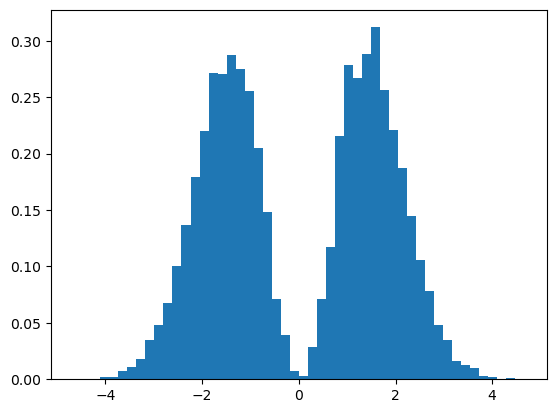

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

N = 10000
mean = 0
std = 1

# -- Generate random data, using built-in numpy func --
random = np.random.normal(mean, std, size=(N,3))
length = np.sum(random**2, axis=1) # length of gaussian vector
result = np.sqrt(length) # length of gaussian vector is chi distribution with 3 dof

signs = np.random.choice(a=[-1, 1], size=N) # because of std = 1 and mean = 0 
final = signs * result

mean_final = np.mean(final)
std_final = np.std(final)

print(f"Final calculated mean of p(x): {mean_final}")
print(f"Final calculated std of p(x) = {std_final}")

plt.hist(final, bins=50, density=True)
plt.show()


Part (a)
Mean: 0.02195
Std : 1.71937


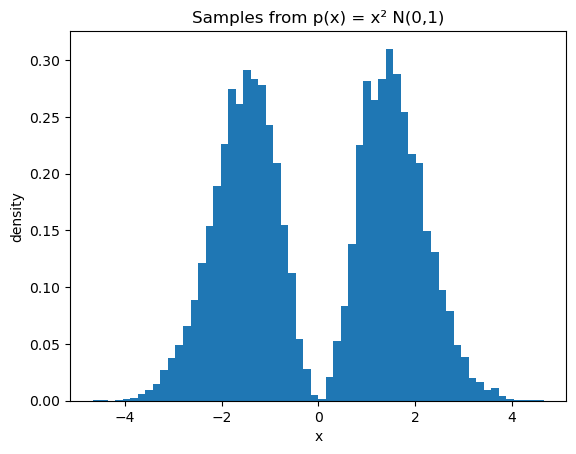

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

N = 10_000

# -------------------------
# Part (a): sample prior p(x)
# -------------------------
u = np.random.normal(0, 1, size=(N, 3))
r = np.sqrt(np.sum(u**2, axis=1))

signs = np.random.choice([-1, 1], size=N)
x = signs * r

print("Part (a)")
print("Mean:", round(np.mean(x), 5))
print("Std :", round(np.std(x, ddof=1), 5))

plt.figure()
plt.hist(x, bins=60, density=True)
plt.title("Samples from p(x) = x² N(0,1)")
plt.xlabel("x")
plt.ylabel("density")
plt.show()


Part (b)
Mean: 0.48486
Std : 0.29862


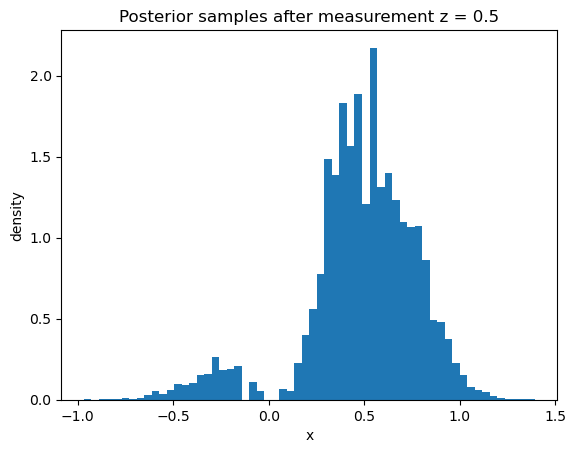

In [2]:
# -------------------------
# Part (b): measurement update
# z = 2x + epsilon, epsilon ~ N(0, 0.3)
# measurement z = 0.5
# -------------------------
z = 0.5
noise_var = 0.3

log_weights = -0.5 * (z - 2*x)**2 / noise_var

# numerical stabilization
log_weights -= np.max(log_weights)
weights = np.exp(log_weights)
weights /= np.sum(weights)

# resample posterior particles
indices = np.random.choice(np.arange(N), size=N, replace=True, p=weights)
x_post = x[indices]

print("\nPart (b)")
print("Mean:", round(np.mean(x_post), 5))
print("Std :", round(np.std(x_post, ddof=1), 5))

plt.figure()
plt.hist(x_post, bins=60, density=True)
plt.title("Posterior samples after measurement z = 0.5")
plt.xlabel("x")
plt.ylabel("density")
plt.show()